# Day3 - Quantum Error Correction Technique : 9-Qubit Shor Code
The 9-Qubit Shor code is the one of the foundational quantum error correcting codes. it protects a single logical qubit code against an arbitary sigle qubit error by combining protection against bit flip and phase flip errors. In this notebook we will cover :
- Logical and Physical qubit
- Structure of 9-Qubit Shor Code
- Bit flip and Phase flip error
- Syndrome extraction 
- Conditional correction
- Decoding
- Measurement
- Qiskit implementation
- Construction of logical state $|0_L\rangle $ and $|1_L\rangle $
- Visualization 

At the end,we will analyze there covered logical measurement distribution and verify whether the injected physical error has been successsfully corrected. let' deep dive into 9-Qubit shor Code.

## Introduction To the Shor Code
The Shor code encode the logical qubit into physical qubit.A Quantum state can experience different errors.the most important basic errors are Bit flip errors and phase flip errors we seen previously.

The Shor code combines two types of repition code ideas. three Qubit block provides protection against bit flip,while the relation ship between the three blocks provides protection against phase flip .The nine physical qubit organized as:

(q0,q1,q2)

(q3,q4,q5)

(q6,q7,q8)

This structure make the shor codes auseful introduction to concatenated quantum error correction.
### Why is the shor code needed?
A classical repition code can protect a bit by storing it multiple times. Quantum information is more difficult beacause an unknown  quantum state cannot simple be copied . The shor Code solve this by encoding the information into an entagked 9-Qubit State.

The Pauli X operator produces a Bit Flip:
- $X|0\rangle = |1\rangle$ and  $X|1\rangle = |0\rangle$

The Pauli Z operator produces a Phase Flip:
- $X|0\rangle = |0\rangle$ and  $X|1\rangle = |-1\rangle$

A Y-error can be expressed as:
- Y=iXZ

Therefore ,if a code can correct both X and Z componenents of a single -qubit error ,it can also correct a single Y error


## Mathematical Background 
The Shor Code encodes the computational basis states as :
- $|0_L\rangle = \frac{1}{2\sqrt{2}}(|000\rangle +|111\rangle)\otimes{3} $
- $|1_L\rangle = \frac{1}{2\sqrt{2}}(|000\rangle -|111\rangle)\otimes{3} $

For an Arbitary Logical state ,
- $|\phi\rangle=\alpha|0\rangle + \beta|1\rangle $

the encoded state becomes:
- $|\phi_L\rangle=\alpha|0_L\rangle+\beta|1_L\rangle $

The important pointis that the logical information is distributed across nine physical qubit rather than being stored in a single Qubit.

## Prepare the Logical State
We First Prepare one logical input qubit. 

for this demonstartion we use the state :
$|+\rangle=\frac{|0\rangle+|1\rangle}{2\sqrt{2}}$

This stateis created using the hadamard gate .The remaining eight qubits will later become part of the encoded 9-Qubit logical state . We use sepearate ancilla qubit for syndrome extraction.

## Import Required Libraries

In [2]:
from qiskit import QuantumCircuit,QuantumRegister,ClassicalRegister
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

## Bulid Basic Structure of Circuit and logical Qubit Preparation

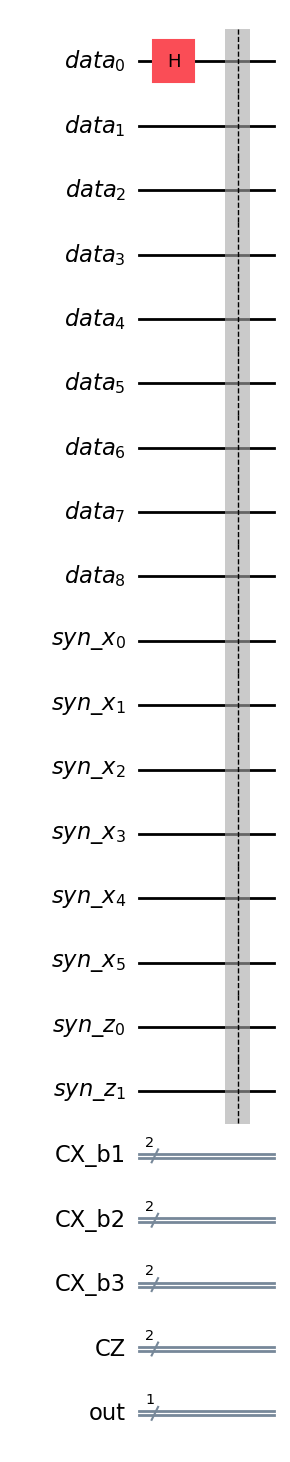

In [9]:
# 9 Physical Data Qubits
data=QuantumRegister(9,"data")

# Ancilla for syndrome extraction
syn_x=QuantumRegister(6,"syn_x")
syn_z=QuantumRegister(2,"syn_z")

# Classicla Syndrom Register
cx_block1=ClassicalRegister(2,"CX_b1")
cx_block2=ClassicalRegister(2,"CX_b2")
cx_block3=ClassicalRegister(2,"CX_b3")
cz=ClassicalRegister(2,"CZ")

# Classical register for recover logical Qubit
out =ClassicalRegister(1,"out")

qc=QuantumCircuit(data,syn_x,syn_z,cx_block1,cx_block2,cx_block3,cz,out)

# Prepare |+>
qc.h(data[0])
qc.barrier()
qc.draw('mpl')

## Step 2 : Encode The Logical Qubit
The Shor Encoder Has two main Ideas.

First ,The logical information is distributed in three intermediate Qubit.

Second, each intermediate qubit is distributed into three-qubit repetition block.

Therefore , 1 logical Qubit -> 3 intermediate qubits -> 9 Physial qubits.

The Three Physical Blocks are :
- Block 1 : q0,q1,q2
- Block 1 : q3,q4,q5
- Block 1 : q6,q7,q8

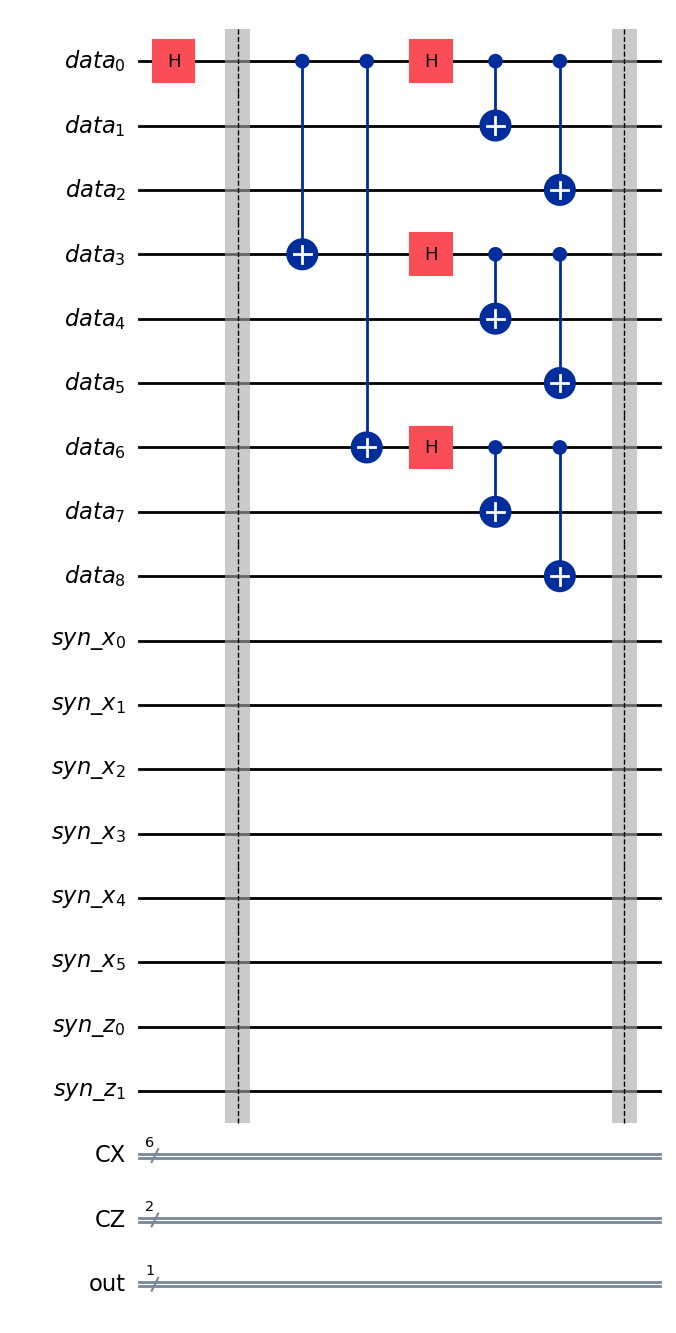

In [5]:
def shor_encode(qc,q):
    # Encode One logical Qubit into 9-Qubit Shor Code
    # Distributed logical information across the block
    qc.cx(q[0],q[3])
    qc.cx(q[0],q[6])

    # Move to the phase sensitive basis
    qc.h(q[0])
    qc.h(q[3])
    qc.h(q[6])

    # Three- Qubit repetition code for block 1
    qc.cx(q[0],q[1])
    qc.cx(q[0],q[2])

    #Three- Qubit repetition code for block 2
    qc.cx(q[3],q[4])
    qc.cx(q[3],q[5])

    # Three- Qubit repetition code for block 3
    qc.cx(q[6],q[7])
    qc.cx(q[6],q[8])

shor_encode(qc,data)
qc.barrier()
qc.draw("mpl")

## Step 3 : Introduce a Single-Qubit Error
we now delibratly introduced  an error into one physical qubit.we will use Y error on q4:

Y=iXZ

Threfore ,this single error contains both a bit flip and phase flip components. q4 belong to the second block : (q3,q4,q5). the purpose of the next stage is to detect these error components through syndrome measurement and apply the appropriate correction.

In [6]:
## Inject a single qubit Y error on physical qubit q4
qc.y(data[4])
qc.barrier()
print("Inject Error : Y on Physical Qubit q4")

Inject Error : Y on Physical Qubit q4


## Step 4 : Extract the Error Syndrome
 The Syndrome gives us information about the error without directly measuring the encoded logical state .for bit flip detetection ,we compare neighbouring qubits withon each three qubit block using the parity checks. for each block we use :
$Z_0Z_1$  and  $Z_1Z_2$

This gives two syndrome bit per block. for phase flip detection, we compare three block using X-type Parity checks .The six Bit flip syndrome bits and two phase flip syndrome bits are stored in classical register . 

The resulting syndrome tells us which correction should be applied .

In [10]:
def measure_ZZ_check(qc,q1,q2,ancilla,cbit):
    # Measure Z parity between two data qubit
    qc.cx(q1,ancilla)
    qc.cx(q2,ancilla)
    qc.measure(ancilla,cbit)

def measure_x_block_check(qc,qubits,ancilla,cbit):
    # measure X parity of a group of a qubit
    qc.h(ancilla)

    for qubit in qubits:
        qc.cx(ancilla,qubit)
    qc.h(ancilla)
    qc.measure(ancilla,cbit)

# Bit Flip Checks : Two checks for each blocks
# Block 1:
measure_ZZ_check(qc,data[0],data[1],syn_x[0],cx_block1[0])
measure_ZZ_check(qc,data[1],data[2],syn_x[1],cx_block1[1])

# Block 2:
measure_ZZ_check(qc,data[3],data[4],syn_x[2],cx_block2[0])
measure_ZZ_check(qc,data[4],data[5],syn_x[3],cx_block2[1])

#Block 3:
measure_ZZ_check(qc,data[6],data[7],syn_x[4],cx_block3[0])
measure_ZZ_check(qc,data[7],data[8],syn_x[5],cx_block3[1])

# Phase_Flip Checks between Blocks
measure_x_block_check(qc,data[0:6],syn_z[0],cz[0])
measure_x_block_check(qc,data[3:9],syn_z[1],cz[1])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "data"), index=0>, <Qubit register=(9, "data"), index=1>, <Qubit register=(9, "data"), index=2>, <Qubit register=(9, "data"), index=3>, <Qubit register=(9, "data"), index=4>, <Qubit register=(9, "data"), index=5>, <Qubit register=(9, "data"), index=6>, <Qubit register=(9, "data"), index=7>, <Qubit register=(9, "data"), index=8>, <Qubit register=(6, "syn_x"), index=0>, <Qubit register=(6, "syn_x"), index=1>, <Qubit register=(6, "syn_x"), index=2>, <Qubit register=(6, "syn_x"), index=3>, <Qubit register=(6, "syn_x"), index=4>, <Qubit register=(6, "syn_x"), index=5>, <Qubit register=(2, "syn_z"), index=0>, <Qubit register=(2, "syn_z"), index=1>), clbits=())

## Step 5 : Apply Syndrome based Correction
 The bit flip syndrome identifies the locaton of an x components inside each three qubit block,for a block syndrom follows this pattern :
 - 00 : No bit-flip error
 - 01 : Error on third qubit
 - 11 : Error on middle qubit
 - 10 : Error on first qubit

 The phase flip syndrome identifies which of the three block contain the phase error . we use Qiskit's conditional control flow to apply X or Z correction only when the corrosponding syndrome is detected.

In [11]:
# Correct bit flip errors

# Block 1 : q0,q1,q2
with qc.if_test((cx_block1,1)):
    qc.x(data[0])
with qc.if_test((cx_block1,3)):
    qc.x(data[1])
with qc.if_test((cx_block1,2)):
    qc.x(data[2])

# Block 2 : q3,q4,q5
with qc.if_test((cx_block2,1)):
    qc.x(data[3])
with qc.if_test((cx_block2,3)):
    qc.x(data[4])
with qc.if_test((cx_block2,2)):
    qc.x(data[5])

# Block 3 : q6,q7,q8
with qc.if_test((cx_block3,1)):
    qc.x(data[6])
with qc.if_test((cx_block3,3)):
    qc.x(data[7])
with qc.if_test((cx_block3,2)):
    qc.x(data[8])

# Correct Phase Flip Error

# Phase Error in Block 1
with qc.if_test((cz,1)):
    qc.z(data[0])

# Phase Error in Block 2
with qc.if_test((cz,3)):
    qc.z(data[3])

# Phase Error in Block 2
with qc.if_test((cz,2)):
    qc.z(data[6])

qc.barrier()

print("Syndrome-based correction is added")


Syndrome-based correction is added


## Decode and Measure 
Once the physical error has been corrected ,the encoded state can be decoded .encoding is represented by unitary operation U. since Quantum gate are reversible ,decoding can be performed using: $U^\dag$

We appply the inverse of shor encoder .after decoding ,the first physical qubit cotains the recovered logical state. because the original state was $ |+\rangle$ ,we expect approximatly equal probabilities for logical 0 and 1.

In [12]:
#Build the encoder seperately so its inverse can be used for decoding
encoder= QuantumCircuit(9)
shor_encode(encoder,encoder.qubits)

# Decode the corrected nine qubit state
qc.compose(encoder.inverse(),qubits=list(data),inplace=True)

# Measure the recovered logical qubits
qc.measure(data[0],out[0])

# Run the complete circuit
result=AerSimulator().run(qc,shots=2048).result()
counts=result.get_counts()

print("recovered Logical Measurement")
print(counts)

recovered Logical Measurement
{'0 00 00 00 01': 127, '1 00 00 00 00': 149, '1 10 00 00 00': 128, '1 11 00 00 01': 132, '0 11 00 00 01': 135, '1 01 00 00 00': 127, '0 10 00 00 01': 127, '1 11 00 00 00': 125, '1 10 00 00 01': 118, '1 00 00 00 01': 113, '0 00 00 00 00': 109, '0 01 00 00 01': 113, '0 11 00 00 00': 137, '0 10 00 00 00': 135, '0 01 00 00 00': 144, '1 01 00 00 01': 129}


## Visualize The Recover Logical State
we now convert the measurement counts into probabilities and visualize them. The x-axis represents the logical measurement outcome:
0 and 1 
The Y-axis represents the measured probabilities .since the original logical state was |+> ,the ideal result is:
P(0)=0.5 and P(1)=0.5 

if the shor correction successfully removed the injected error , the recover logical state should remain close to this distribution.

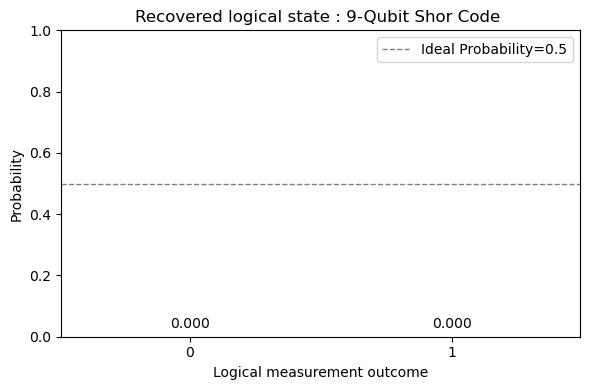

In [17]:
# Convert count into probabilities
shots=sum(counts.values())

p0=counts.get("0",0)/shots
p1=counts.get("1",0)/shots

fig,ax=plt.subplots(figsize=(6,4))
ax.bar(["0","1"],[p0,p1],color=["steelblue","darkorange"])

ax.set_xlabel("Logical measurement outcome")
ax.set_ylabel("Probability")
ax.set_title("Recovered logical state : 9-Qubit Shor Code ")
ax.set_ylim(0,1)


ax.text(0,p0+0.03,f"{p0:.3f}",ha="center")
ax.text(1,p0+0.03,f"{p1:.3f}",ha="center")

ax.axhline(0.5,color="gray",linestyle="--",linewidth=1,label="Ideal Probability=0.5")

ax.legend()
plt.tight_layout()
plt.show()

### Result Interpretation
The x-axis shows the final logiacal measurement outcome,while the y-axis shows its probability. Because we initially prepared |+> and ideal free logical measurement gives approximatly 50% for 0 and 50% for 1 . 

The important observation is that a physical Y error was delibratly introduced on q4,but the error correction procedure recover the logical information .small deviation from 0.5 are expecetd beacause the simulation uses te finite number of shots .

This demonstatrte the central idea of an shor code .information can be distributed accross multiple physial qubit  so that single physical qubit error can be detected and corrected without directly measuring the logical qauntum state.

## Conclusion
The 9 qubit shor code encoded one logical qubit into 9 physical qubit using the combination of repitition code structure .it protect against both bit flip and pahse flip error and therefore it provide protection against single qubit Puali error.

In this notebook we prepared a logical |+> state,encode it using shor code ,introduced Y error on Physical Qubit,extracted error syndrome ,applied condition correction and decoded state .the final measurement shows that the logical information remained recoverable despite the injected physical error .this demonstarate how qunatum error correction sepearte the physical qubit from the logical informationthey collectively represent .

The shor code is not intended to be an effiecient large scale QEC architecture ,but it is important foundation for understanding stabilizers,syndrome extraction ,logical qubit and cocatenation code.this concepts lead natually toward more efficient code such as steane code and surface code.


--

**Author:** *Shreya Palase*  

**Date Created:**  *6-sep-2026*

**project:** Quantum-Error-Correction-Techniques

**File:** Day3-Shore_Code.ipynb

Thank you and Keep Learning!

<sub>© Shreya Palase- All Rights Reserved.This notebook is part of a structured learning series designed for Github publication.</sub>